In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

In [59]:
TICKERS = ["SPY", "QQQ", "IWM"]

START = "2016-01-01"
END = "2026-01-01"

In [60]:
raw = yf.download(
    TICKERS,
    start=START,
    end=END,
    interval="1d",
    auto_adjust=False,
    progress=False
)

raw.head()

Price       Adj Close                               Close              \
Ticker            IWM         QQQ         SPY         IWM         QQQ   
Date                                                                    
2016-01-04  96.235367  101.605629  169.471558  110.010002  109.500000   
2016-01-05  96.445343  101.429314  169.758179  110.250000  109.309998   
2016-01-06  94.975677  100.455032  167.616821  108.570000  108.260002   
2016-01-07  92.438789   97.309425  163.595444  105.669998  104.870003   
2016-01-08  90.846687   96.511414  161.799744  103.849998  104.010002   

Price                         High                                 Low  \
Ticker             SPY         IWM         QQQ         SPY         IWM   
Date                                                                     
2016-01-04  201.020004  110.830002  109.599998  201.029999  109.080002   
2016-01-05  201.360001  110.580002  110.180000  201.899994  109.550003   
2016-01-06  198.820007  109.599998  108.889999  200.059998  108.000000   
2016-01-07  194.050003  107.500000  107.290001  197.440002  105.489998   
2016-01-08  191.919998  106.489998  106.290001  195.850006  103.660004   

Price                                     Open                          \
Ticker             QQQ         SPY         IWM         QQQ         SPY   
Date                                                                     
2016-01-04  108.120003  198.589996  110.610001  109.449997  200.490005   
2016-01-05  108.800003  200.050003  110.410004  110.040001  201.399994   
2016-01-06  107.410004  197.600006  108.699997  107.410004  198.339996   
2016-01-07  104.809998  193.589996  106.720001  105.949997  195.330002   
2016-01-08  103.900002  191.580002  105.870003  105.629997  195.190002   

Price         Volume                       
Ticker           IWM       QQQ        SPY  
Date                                       
2016-01-04  66665900  50807600  222353500  
2016-01-05  28253300  38795200  110845800  
2016-01-06  35569200  41891100  152112600  
2016-01-07  52482000  61386300  213436100  
2016-01-08  60299300  69344000  209817200

In [61]:
raw.shape

(2514, 18)

In [62]:
raw.columns

MultiIndex([('Adj Close', 'IWM'),
            ('Adj Close', 'QQQ'),
            ('Adj Close', 'SPY'),
            (    'Close', 'IWM'),
            (    'Close', 'QQQ'),
            (    'Close', 'SPY'),
            (     'High', 'IWM'),
            (     'High', 'QQQ'),
            (     'High', 'SPY'),
            (      'Low', 'IWM'),
            (      'Low', 'QQQ'),
            (      'Low', 'SPY'),
            (     'Open', 'IWM'),
            (     'Open', 'QQQ'),
            (     'Open', 'SPY'),
            (   'Volume', 'IWM'),
            (   'Volume', 'QQQ'),
            (   'Volume', 'SPY')],
           names=['Price', 'Ticker'])

In [63]:
raw.head

<bound method NDFrame.head of Price        Adj Close                               Close              \
Ticker             IWM         QQQ         SPY         IWM         QQQ   
Date                                                                     
2016-01-04   96.235367  101.605629  169.471558  110.010002  109.500000   
2016-01-05   96.445343  101.429314  169.758179  110.250000  109.309998   
2016-01-06   94.975677  100.455032  167.616821  108.570000  108.260002   
2016-01-07   92.438789   97.309425  163.595444  105.669998  104.870003   
2016-01-08   90.846687   96.511414  161.799744  103.849998  104.010002   
...                ...         ...         ...         ...         ...   
2025-12-24  251.662796  622.460266  686.730530  252.710007  623.929993   
2025-12-26  250.378143  622.420288  686.660889  251.419998  623.890015   
2025-12-29  248.844528  619.407410  684.213867  249.880005  620.869995   
2025-12-30  247.002182  617.970764  683.378296  248.029999  619.429993   
2025-12-

In [64]:
raw.tail

<bound method NDFrame.tail of Price        Adj Close                               Close              \
Ticker             IWM         QQQ         SPY         IWM         QQQ   
Date                                                                     
2016-01-04   96.235367  101.605629  169.471558  110.010002  109.500000   
2016-01-05   96.445343  101.429314  169.758179  110.250000  109.309998   
2016-01-06   94.975677  100.455032  167.616821  108.570000  108.260002   
2016-01-07   92.438789   97.309425  163.595444  105.669998  104.870003   
2016-01-08   90.846687   96.511414  161.799744  103.849998  104.010002   
...                ...         ...         ...         ...         ...   
2025-12-24  251.662796  622.460266  686.730530  252.710007  623.929993   
2025-12-26  250.378143  622.420288  686.660889  251.419998  623.890015   
2025-12-29  248.844528  619.407410  684.213867  249.880005  620.869995   
2025-12-30  247.002182  617.970764  683.378296  248.029999  619.429993   
2025-12-

In [65]:
raw.isna().sum()

Price      Ticker
Adj Close  IWM       0
           QQQ       0
           SPY       0
Close      IWM       0
           QQQ       0
           SPY       0
High       IWM       0
           QQQ       0
           SPY       0
Low        IWM       0
           QQQ       0
           SPY       0
Open       IWM       0
           QQQ       0
           SPY       0
Volume     IWM       0
           QQQ       0
           SPY       0
dtype: int64

In [66]:
adj_close = raw["Adj Close"].copy()

adj_close.head()

Ticker,IWM,QQQ,SPY
Date,,,
2016-01-04,96.235367,101.605629,169.471558
2016-01-05,96.445343,101.429314,169.758179
2016-01-06,94.975677,100.455032,167.616821
2016-01-07,92.438789,97.309425,163.595444
2016-01-08,90.846687,96.511414,161.799744


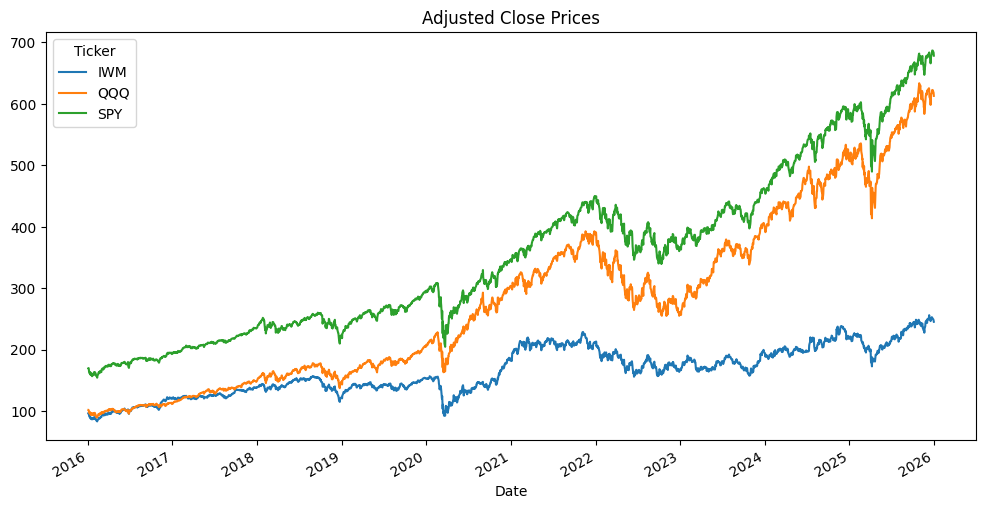

In [67]:
adj_close.plot(
    figsize=(12, 6),
    title="Adjusted Close Prices"
)

plt.show()

In [68]:
spy = pd.DataFrame()

spy["close"] = raw["Adj Close"]["SPY"]
spy["volume"] = raw["Volume"]["SPY"]

spy.head()

,close,volume
Date,,
2016-01-04,169.471558,222353500
2016-01-05,169.758179,110845800
2016-01-06,167.616821,152112600
2016-01-07,163.595444,213436100
2016-01-08,161.799744,209817200


In [69]:
spy["ret_1d"] = spy["close"].pct_change(1)

In [70]:
spy[["close", "ret_1d"]].head(10)

,close,ret_1d
Date,,
2016-01-04,169.471558,NaN
2016-01-05,169.758179,0.001691
2016-01-06,167.616821,-0.012614
2016-01-07,163.595444,-0.023991
2016-01-08,161.799744,-0.010976
2016-01-11,161.959915,0.000990
2016-01-12,163.266632,0.008068
2016-01-13,159.194672,-0.024941
2016-01-14,161.808197,0.016417


In [71]:
p0 = spy["close"].iloc[0]
p1 = spy["close"].iloc[1]

manual_return = p1 / p0 - 1

print(manual_return)
print(spy["ret_1d"].iloc[1])

0.0016912637010007003
0.0016912637010007003


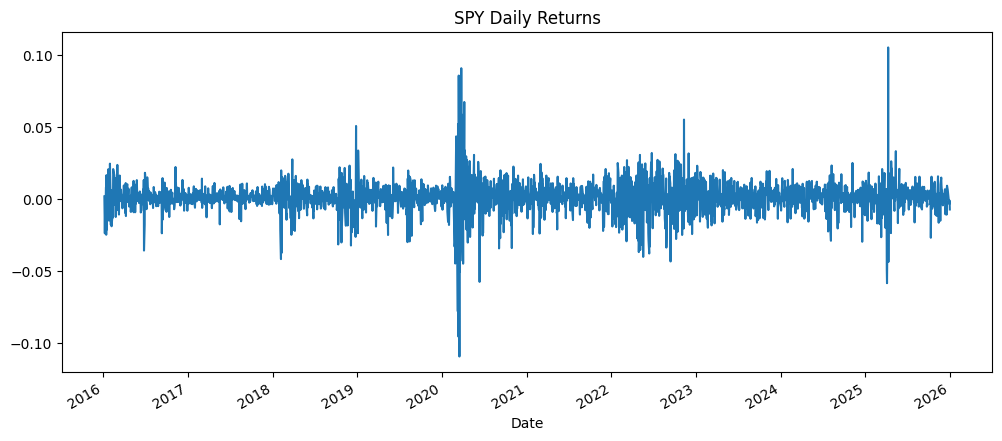

In [72]:
spy["ret_1d"].plot(
    figsize=(12, 5),
    title="SPY Daily Returns"
)

#plt.axhline(0)
plt.show()

In [73]:
spy['ret_5d'] = spy['close'].pct_change(5)
spy['ret_20d'] = spy['close'].pct_change(20)

spy[['ret_1d','ret_5d','ret_20d']].tail()

,ret_1d,ret_5d,ret_20d
Date,,,
2025-12-24,0.003518,0.031308,0.025777
2025-12-26,-0.000101,0.023475,0.018641
2025-12-29,-0.003564,0.010667,0.009500
2025-12-30,-0.001221,0.003183,0.012892
2025-12-31,-0.007409,-0.008780,0.003529


11. Rolling volatility

In [74]:
spy["vol_20d"] = (
    spy["ret_1d"]
    .rolling(window=20)
    .std()
)

spy["vol_20d_ann"] = (
    spy["vol_20d"] * np.sqrt(252)
)

In [75]:
spy["vol_20d_ann"].tail()

Date
2025-12-24    0.089319
2025-12-26    0.086907
2025-12-29    0.086583
2025-12-30    0.084790
2025-12-31    0.089307
Name: vol_20d_ann, dtype: float64

12. volatility clustering

<Axes: title={'center': 'SPY 20-Day Annualized Volatility'}, xlabel='Date'>

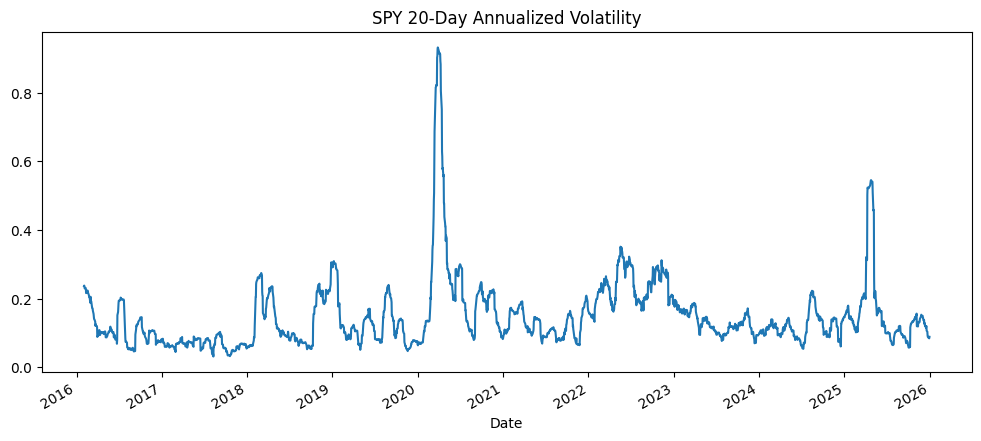

In [76]:
spy["vol_20d_ann"].plot(
    figsize=(12, 5),
    title="SPY 20-Day Annualized Volatility"
)

#plt.show()

13. Moving average

<Axes: xlabel='Date'>

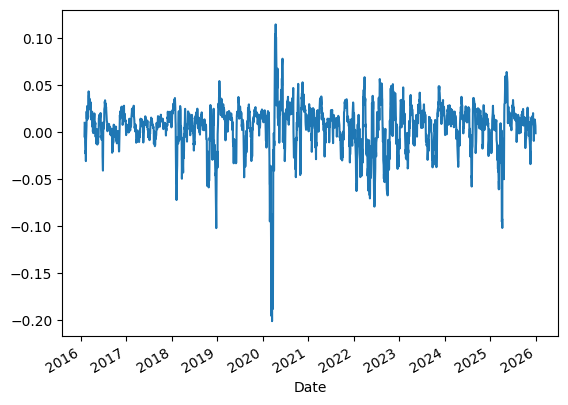

In [77]:
spy["ma_20"] = (
    spy["close"]
    .rolling(20)
    .mean()
)

spy['ma_20_dist'] = (spy['close']/spy['ma_20'] - 1)

spy['ma_20_dist'].plot()

14. Mean-reversion feature：rolling z-score

<Axes: xlabel='Date'>

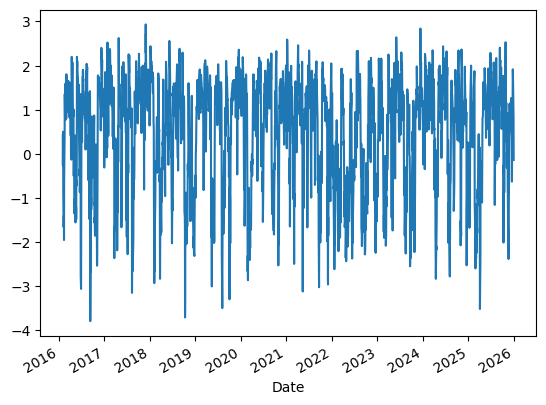

In [78]:
rolling_mean = spy['close'].rolling(20).mean()
rolling_std = spy['close'].rolling(20).std()

spy['zscore_20d'] = (spy['close'] - rolling_mean) / rolling_std

spy['zscore_20d'].plot()


15. financial explanation of z-score

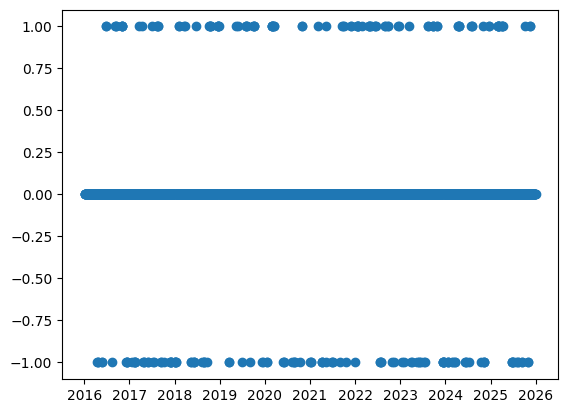

In [79]:
signal = np.where(
    spy["zscore_20d"] < -2,
    1,
    np.where(
        spy["zscore_20d"] > 2,
        -1,
        0
    )
)

plt.scatter(spy.index,signal)

In [80]:
spy[[
    "close",
    "ma_20",
    "zscore_20d"
]].head(25)

,close,ma_20,zscore_20d
Date,,,
2016-01-04,169.471558,NaN,NaN
2016-01-05,169.758179,NaN,NaN
2016-01-06,167.616821,NaN,NaN
2016-01-07,163.595444,NaN,NaN
2016-01-08,161.799744,NaN,NaN
2016-01-11,161.959915,NaN,NaN
2016-01-12,163.266632,NaN,NaN
2016-01-13,159.194672,NaN,NaN
2016-01-14,161.808197,NaN,NaN


Volume feature

<Axes: xlabel='Date'>

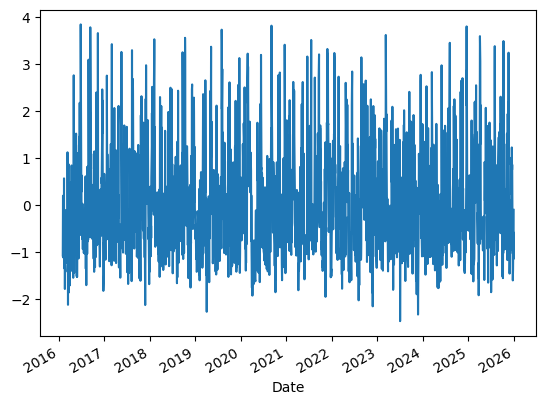

In [81]:
volumn_mean_20 = spy['volume'].rolling(20).mean()
volumn_std_20 = spy['volume'].rolling(20).std()

spy['volume_zscore_20d'] = (spy['volume'] - volumn_mean_20) / volumn_std_20

spy['volume_zscore_20d'].plot()

18. Lagged returns

In [82]:
spy['ret_lag1'] = spy['ret_1d'].shift(1)
spy['ret_lag2'] = spy['ret_1d'].shift(2)
spy['ret_lag3'] = spy['ret_1d'].shift(3)


19. create target

In [83]:
spy['next_return'] = spy['ret_1d'].shift(-1)

20. data structure

In [84]:
spy.head()

,close,volume,ret_1d,ret_5d,ret_20d,vol_20d,vol_20d_ann,ma_20,ma_20_dist,zscore_20d,volume_zscore_20d,ret_lag1,ret_lag2,ret_lag3,next_return
Date,,,,,,,,,,,,,,,
2016-01-04,169.471558,222353500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001691
2016-01-05,169.758179,110845800,0.001691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.012614
2016-01-06,167.616821,152112600,-0.012614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001691,NaN,NaN,-0.023991
2016-01-07,163.595444,213436100,-0.023991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.012614,0.001691,NaN,-0.010976
2016-01-08,161.799744,209817200,-0.010976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.023991,-0.012614,0.001691,0.000990


21. Classification target

In [85]:
spy['target_up'] = (spy['next_return'] > 0).astype(int)

22. create feature matrix

In [86]:
FEATURES = [
    "ret_1d",
    "ret_5d",
    "ret_20d",
    "vol_20d",
    "ma_20_dist",
    "zscore_20d",
    "volume_zscore_20d",
    "ret_lag1",
    "ret_lag2",
    "ret_lag3",
]

model_data = spy[
    FEATURES + ["next_return"]
].copy()

model_data = model_data.dropna()

In [87]:
len(model_data), len(spy)

(2493, 2514)

In [88]:
model_data["target_up"] = (
    model_data["next_return"] > 0
).astype(int)

In [89]:
model_data.head()

,ret_1d,ret_5d,ret_20d,vol_20d,ma_20_dist,zscore_20d,volume_zscore_20d,ret_lag1,ret_lag2,ret_lag3,next_return,target_up
Date,,,,,,,,,,,,
2016-02-02,-0.018022,-0.000210,-0.054024,0.014924,-0.005445,-0.263379,-0.150887,-0.000361,0.024377,0.005209,0.005995,1
2016-02-03,0.005995,0.016850,-0.049960,0.015021,0.003157,0.191095,0.202039,-0.018022,-0.000361,0.024377,0.001568,1
2016-02-04,0.001568,0.013167,-0.036314,0.014850,0.006636,0.500888,-1.109609,0.005995,-0.018022,-0.000361,-0.019050,0
2016-02-05,-0.019050,-0.029786,-0.031436,0.014497,-0.010956,-0.861976,-0.245089,0.001568,0.005995,-0.018022,-0.013461,0
2016-02-08,-0.013461,-0.042499,-0.033868,0.014593,-0.022598,-1.661787,-0.009513,-0.019050,0.001568,0.005995,0.000054,1


In [90]:
model_data.tail()

,ret_1d,ret_5d,ret_20d,vol_20d,ma_20_dist,zscore_20d,volume_zscore_20d,ret_lag1,ret_lag2,ret_lag3,next_return,target_up
Date,,,,,,,,,,,,
2025-12-23,0.004570,0.016384,0.031796,0.005897,0.011279,1.659108,-0.670662,0.006230,0.009064,0.007551,0.003518,1
2025-12-24,0.003518,0.031308,0.025777,0.005627,0.013544,1.915906,-1.598298,0.004570,0.006230,0.009064,-0.000101,0
2025-12-26,-0.000101,0.023475,0.018641,0.005475,0.012502,1.654518,-1.369187,0.003518,0.004570,0.006230,-0.003564,0
2025-12-29,-0.003564,0.010667,0.009500,0.005454,0.008415,1.077915,-0.576817,-0.000101,0.003518,0.004570,-0.001221,0
2025-12-30,-0.001221,0.003183,0.012892,0.005341,0.006538,0.833892,-1.143822,-0.003564,-0.000101,0.003518,-0.007409,0


23. sanity check

In [91]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2493 entries, 2016-02-02 to 2025-12-30
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ret_1d             2493 non-null   float64
 1   ret_5d             2493 non-null   float64
 2   ret_20d            2493 non-null   float64
 3   vol_20d            2493 non-null   float64
 4   ma_20_dist         2493 non-null   float64
 5   zscore_20d         2493 non-null   float64
 6   volume_zscore_20d  2493 non-null   float64
 7   ret_lag1           2493 non-null   float64
 8   ret_lag2           2493 non-null   float64
 9   ret_lag3           2493 non-null   float64
 10  next_return        2493 non-null   float64
 11  target_up          2493 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 253.2 KB


In [92]:
model_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ret_1d,2493.0,0.000639,0.011315,-0.109424,-0.003556,0.000731,0.005943,0.105019
ret_5d,2493.0,0.003179,0.023112,-0.179693,-0.006475,0.004882,0.015156,0.173582
ret_20d,2493.0,0.012590,0.044129,-0.309868,-0.006081,0.018543,0.036675,0.230726
vol_20d,2493.0,0.009391,0.006494,0.002010,0.005559,0.007631,0.011625,0.058701
ma_20_dist,2493.0,0.005660,0.024939,-0.200798,-0.003696,0.009858,0.019306,0.114525
zscore_20d,2493.0,0.508933,1.242710,-3.793759,-0.301913,0.887873,1.456837,2.933565
volume_zscore_20d,2493.0,-0.019159,1.061524,-2.463844,-0.788050,-0.234589,0.560939,3.842396
ret_lag1,2493.0,0.000639,0.011315,-0.109424,-0.003556,0.000731,0.005943,0.105019
ret_lag2,2493.0,0.000650,0.011325,-0.109424,-0.003539,0.000732,0.005949,0.105019
ret_lag3,2493.0,0.000652,0.011325,-0.109424,-0.003539,0.000737,0.005949,0.105019


24. check classification balance

In [93]:
model_data["target_up"].value_counts()

target_up
1    1385
0    1108
Name: count, dtype: int64

In [94]:
model_data["target_up"].value_counts(normalize=True)

target_up
1    0.555556
0    0.444444
Name: proportion, dtype: float64

25. feature correlation

In [95]:
corr = model_data.corr()
corr['next_return'].sort_values()

ret_1d              -0.134307
ret_lag3            -0.064260
ma_20_dist          -0.051909
ret_5d              -0.051197
ret_20d             -0.038643
ret_lag2            -0.029849
zscore_20d          -0.024024
volume_zscore_20d   -0.014993
vol_20d              0.033015
ret_lag1             0.080129
target_up            0.642195
next_return          1.000000
Name: next_return, dtype: float64

26. z-score and future return

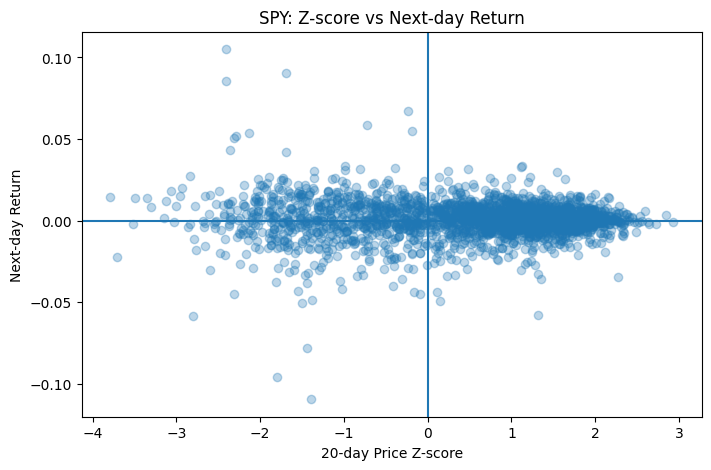

In [96]:
plt.figure(figsize=(8, 5))

plt.scatter(
    model_data["zscore_20d"],
    model_data["next_return"],
    alpha=0.3
)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("20-day Price Z-score")
plt.ylabel("Next-day Return")

plt.title(
    "SPY: Z-score vs Next-day Return"
)

plt.show()

27. conditional analysis

In [97]:
oversold = model_data[
    model_data["zscore_20d"] < -2
]

len(oversold)

109

In [98]:
oversold['next_return'].mean(), model_data['next_return'].mean(), oversold['next_return'].median()

(np.float64(0.004191799957281636),
 np.float64(0.000642896581158831),
 np.float64(0.0023533349189297503))

28. overbought

In [99]:
overbought = model_data[
    model_data["zscore_20d"] > 2
]

In [100]:
print(
    "Overall:",
    model_data["next_return"].mean()
)

print(
    "Oversold:",
    oversold["next_return"].mean()
)

print(
    "Overbought:",
    overbought["next_return"].mean()
)

Overall: 0.000642896581158831
Oversold: 0.004191799957281636
Overbought: -0.000148359740338787


In [104]:
model_data.to_csv(
    "./data/processed/spy_features.csv"
)

In [105]:
processed_data = pd.read_csv("./data/processed/spy_features.csv")

In [106]:
processed_data.columns

Index(['Date', 'ret_1d', 'ret_5d', 'ret_20d', 'vol_20d', 'ma_20_dist',
       'zscore_20d', 'volume_zscore_20d', 'ret_lag1', 'ret_lag2', 'ret_lag3',
       'next_return', 'target_up'],
      dtype='object')

In [110]:
processed_data['ret_1d'].mean(), processed_data['ret_1d'].std()

(np.float64(0.0006386393499227271), np.float64(0.01131532667869677))

In [112]:
processed_data['vol_20d'].median() * np.sqrt(252)

np.float64(0.12113094856907437)

In [118]:
(processed_data['zscore_20d'] < -2).astype(int).sum()

np.int64(109)

In [119]:
processed_data[processed_data['zscore_20d'] < -2]['next_return'].mean()

np.float64(0.004191799957281632)

In [120]:
processed_data[processed_data['zscore_20d'] > 2]['next_return'].mean()


np.float64(-0.00014835974033878735)